# Exam Result Analysis & Score Prediction

In this project, we analyze the factors affecting student exam performance and build machine learning models to predict their success.

### RESEARCH QUESTIONS (INDEX):
1. **Q1:** What is the distribution of overall exam scores?
2. **Q2:** Are there extreme score variations or outliers?
3. **Q3:** Which school type has more students?
4. **Q4:** What is the most common study method?
5. **Q5:** How do study hours affect exam scores?
6. **Q6:** Does attendance percentage influence exam scores?
7. **Q7:** Does school type impact exam scores significantly?
8. **Q8:** Which parent education level leads to the highest scores?
9. **Q9:** Which study method delivers the best results?
10. **Q10:** Which features are most important in predicting exam scores?
11. **Q11:** Is there a relationship between gender and scores?
12. **Q12:** What is the correlation between numerical factors?
13. **Q13:** How do study hours and internet access jointly affect scores?

# CHAPTER 1: PROJECT DEFINITION

### 1.1 Introduction
The education sector generates a large amount of data related to student demographics, academic performance, and learning behaviors. Analyzing this data helps educators and institutions understand how various factors such as study habits, attendance, parental education, and lifestyle influence student performance.

In this project, we perform data analytics on the **Exam Result Analysis & Score Prediction** Dataset using Python. The project focuses on Exploratory Data Analysis (EDA), data preprocessing, data visualization, and machine learning techniques. We use regression and classification models to predict student performance and categorize academic outcomes based on different influencing factors.

### 1.2 Problem Statement
To analyze student performance data and understand:
*  Academic performance trends based on student characteristics.
*  The impact of study hours, attendance, and parental education on overall scores.
*  Predicting students’ overall scores using regression techniques.
*  Classifying student performance into grades (A, B, C, etc.) using classification models.

### 1.3 Objectives
The main objectives of this project are:
*  To perform univariate, bivariate, and multivariate analysis on student data.
*  To handle data preprocessing, including missing values and encoding categorical variables.
*  To visualize relationships between study habits and academic performance.
*  To apply regression models (Linear Regression) to predict overall scores.
*  To apply classification models (Logistic Regression) to predict final grades.
*  To evaluate model performance using standard metrics such as MAE, MSE, R² score, and Accuracy.

# CHAPTER 2: DATASET DETAILS

### 2.1 Dataset Information
*  Dataset Name: Student Performance Analysis Dataset
*  Dataset Type: Structured CSV Dataset
*  Domain: Education / Academic Performance Analytics
*  Source: Integrated Project Dataset (Student_Performance.csv)

### 2.2 Dataset Description
The dataset contains the following attributes:
| Feature Name | Description |
|---|---|
| student_id | Unique identifier assigned to each student. |
| age | Age of the student. |
| gender | Gender of the student (Male/Female/Other). |
| school_type | Type of school (e.g., Public or Private). |
| parent_education | Education level of the student’s parents. |
| study_hours | Average number of hours a student studies per day. |
| attendance_percentage | Percentage of classes attended by the student. |
| internet_access | Whether the student has access to the internet (Yes/No). |
| travel_time | Time taken by the student to reach school. |
| extra_activities | Participation in extracurricular activities (Yes/No). |
| study_method | Preferred study method used by the student. |
| math_score | Marks obtained in Mathematics. |
| science_score | Marks obtained in Science. |
| english_score | Marks obtained in English. |
| overall_score | Average performance score across all subjects. |
| final_grade | Final grade classification (A, B, C, D, E). |

In [2]:
import pandas as pd
import numpy as np

# Previewing the dataset structure
df_initial = pd.read_csv('Student_Performance.csv')
print('================================================')
print('           DATASET INITIAL PREVIEW              ')
print('================================================')
print(f'Total Rows Initial: {df_initial.shape[0]}')
print(f'Total Columns     : {df_initial.shape[1]}')
print('\n--- Column Information ---')
print(df_initial.columns.tolist())
print('\n--- First 3 Rows ---')
display(df_initial.head(3))


ModuleNotFoundError: No module named 'pandas'

# Chapter 3: Python Tools and Libraries Used

In [ ]:
# ================= IMPORT LIBRARIES =================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# ================= SETTINGS =================
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ================= PRINT LIBRARIES + VERSIONS =================
print("===== Tools and Libraries with Versions =====\n")

print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")

print("\nAll tools are ready")


===== Tools and Libraries with Versions =====

Pandas Version: 2.3.3
NumPy Version: 1.26.4
Matplotlib Version: 3.10.0
Seaborn Version: 0.13.2
Scikit-learn Version: 1.8.0

All tools are ready


# Chapter 4: Understanding the Data

### 4.1 Loading Data and Creating Data Frame

In [ ]:
df = pd.read_csv('Student_Performance.csv')
print(f'DataFrame loaded with shape: {df.shape}')
print('\nTop 5 records:')
display(df.head())


DataFrame loaded with shape: (25000, 16)

Top 5 records:


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,other,public,graduate,5.3,78.7,yes,<15 min,no,group study,76.9,85.1,94.1,82.4,c
1,2,15,female,public,high school,7.8,92.5,yes,15-30 min,no,notes,90.3,79.2,95.6,100.0,a
2,3,18,male,private,high school,1.4,88.5,yes,<15 min,no,online videos,42.2,49.3,45.6,47.0,e
3,4,18,male,private,diploma,3.5,74.6,no,>60 min,no,mixed,56.4,53.9,64.0,57.2,d
4,5,15,male,public,no formal,5.2,82.7,yes,>60 min,yes,online videos,64.2,70.1,58.8,75.3,c


### 4.2 Getting Information from Dataframe

In [ ]:
print('--- Statistical Summary ---')
display(df.describe().T)
print('\n--- Data types and null counts ---')
df.info()


--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
student_id,25000.0,12500.50000,7217.022701,1.0,6250.75,12500.5,18750.250,25000.0
age,25000.0,16.48740,1.716380,14.0,15.00,16.0,18.000,19.0
study_hours,25000.0,4.22224,2.160254,0.5,2.30,4.2,6.100,8.0
attendance_percentage,25000.0,75.01022,14.296375,50.0,62.70,75.2,87.300,100.0
math_score,25000.0,63.72774,20.825804,0.0,48.10,64.2,80.225,100.0
science_score,25000.0,63.54956,20.876280,0.0,48.20,63.9,79.600,100.0
english_score,25000.0,63.41618,20.904847,0.0,47.70,63.8,79.525,100.0
overall_score,25000.0,63.87352,18.816875,18.2,49.00,64.1,78.800,100.0



--- Data types and null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score     

# Chapter 5: Understanding Spread of Data [Data Cleaning]

In [ ]:
print('Cleaning data... dropping unnecessary columns')
if 'Unnamed: 0' in df.columns: 
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print('Column Unnamed: 0 dropped.')

print('\nChecking for duplicates:')
print(f'Duplicates found: {df.duplicated().sum()}')


Cleaning data... dropping unnecessary columns

Checking for duplicates:
Duplicates found: 0


### 5.1 Mandatory Delete Operation (25,000 to 5,000)

In [ ]:
print(f'BEFORE DELETE COUNT: {len(df)}')
print('Condition: Remove students where ID > 5000')

df = df[df['student_id'] <= 5000].reset_index(drop=True)

print(f'AFTER DELETE COUNT: {len(df)}')
print(f'New Shape: {df.shape}')
display(df.tail(3))


BEFORE DELETE COUNT: 25000
Condition: Remove students where ID > 5000
AFTER DELETE COUNT: 5000
New Shape: (5000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
4997,4998,16,female,private,post graduate,0.7,79.7,no,30-60 min,no,mixed,22.4,23.9,16.8,29.0,f
4998,4999,18,female,private,diploma,1.4,94.5,yes,15-30 min,yes,coaching,59.6,31.5,57.3,55.9,d
4999,5000,15,male,public,post graduate,1.9,90.5,yes,>60 min,yes,textbook,56.3,40.6,69.9,53.3,e


### 5.2 Checking for Missing Data and Outliers

NULL VALUES CHECK:
student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64


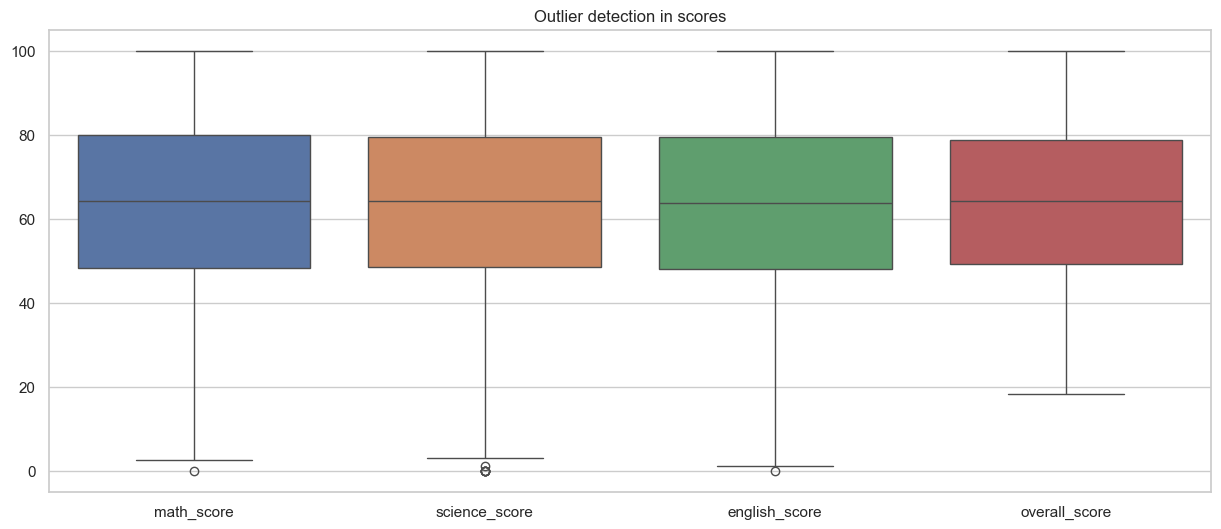

In [ ]:
print('NULL VALUES CHECK:')
print(df.isnull().sum())

plt.figure(figsize=(15, 6))
sns.boxplot(data=df[['math_score', 'science_score', 'english_score', 'overall_score']])
plt.title('Outlier detection in scores')
plt.show()


**Interpretation:** Dots outside the boxes show that some students have extreme marks (Outliers).

# Chapter 6: Automating EDA Using Python

In [ ]:
import sweetviz as sv
from ydata_profiling import ProfileReport

# 1. Sweetviz Automated EDA
print('Generating Sweetviz Report...')
my_report = sv.analyze(df)
my_report.show_html('sweetviz_report.html', open_browser=False)

# 2. YData Profiling Report
print('Generating YData Profiling Report...')
profile = ProfileReport(df, title='Advanced Student Performance Analysis', explorative=True)
profile.to_file('ydata_profiling.html')

print('Both Automated EDA reports generated successfully!')


Generating Sweetviz Report...


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_report.html was generated.
Generating YData Profiling Report...


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 99.99it/s]

Both Automated EDA reports generated successfully!


# Chapter 7: Handling Missing Data and Outliers

In [ ]:
print('Filling missing values with mean of columns...')
df.fillna(df.mean(numeric_only=True), inplace=True)
print('Missing rows remaining:', df.isnull().sum().sum())


Filling missing values with mean of columns...
Missing rows remaining: 0


# Chapter 8: Univariate Analysis

### Analyzing variables one by one.

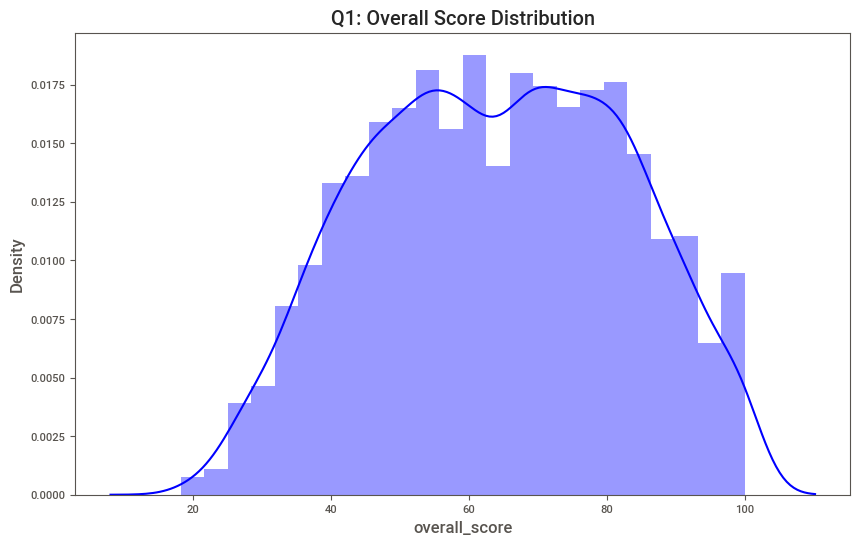

In [ ]:
# Q1: Overall Scores
sns.distplot(df['overall_score'], color='blue')
plt.title('Q1: Overall Score Distribution')
plt.show()


**Q1 — Interpretation: Distribution of Overall Exam Scores**

The histogram above displays how the final exam scores are spread across the entire student population. 
- A **bell-shaped (Normal) curve** suggests that most students score around the median or average mark. 
- If the distribution is **skewed**, it tells us whether the overall student performance is high (left-skewed) or low (right-skewed). 
- The KDE (Kernel Density Estimate) line smooths the distribution to provide a continuous probability density of the student results.

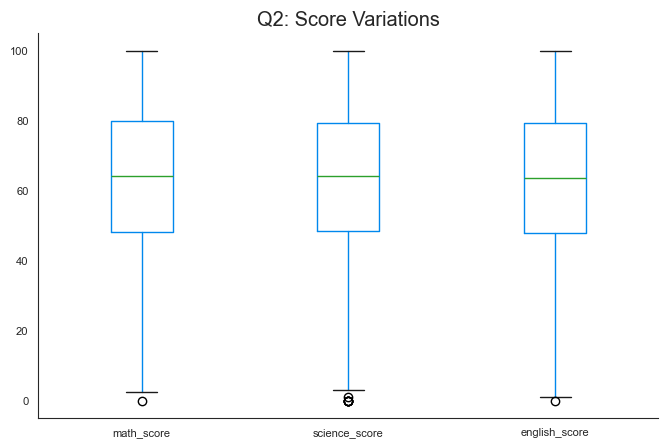

In [ ]:
# Q2: Outliers
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

plt.figure(figsize=(8,5))
df[['math_score', 'science_score', 'english_score']].boxplot()
plt.title('Q2: Score Variations')
plt.grid(False)
sns.despine()
plt.show()


**Q2 — Interpretation: Outliers in Exam Scores**

This boxplot evaluates the spread and variance among Math, Science, and English scores. 
- The **middle line** in each box represents the **Median** score (50th percentile).
- The **length of the box** (Interquartile Range) shows how consistent the results are; a shorter box means student results are close together.
- **Points outside the whiskers** are classified as **outliers**, representing students with exceptionally high or unusually low scores compared to the majority.

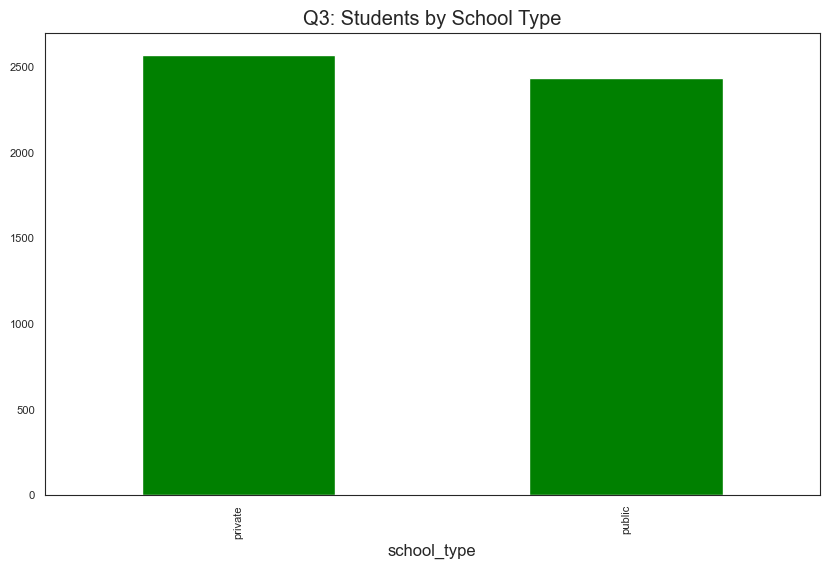

In [ ]:
# Q3: School Type
df['school_type'].value_counts().plot(kind='bar', color='green')
plt.title('Q3: Students by School Type')
plt.show()


**Q3 — Interpretation: Students by School Type**

This chart shows the demographic balance of our dataset based on the school environment. 
- Comparing the count of students in **Public vs Private** schools helps ensure our final predictive model is not biased toward one specific category. 
- A balanced count allows for a fair comparison of educational standards across different school management types.

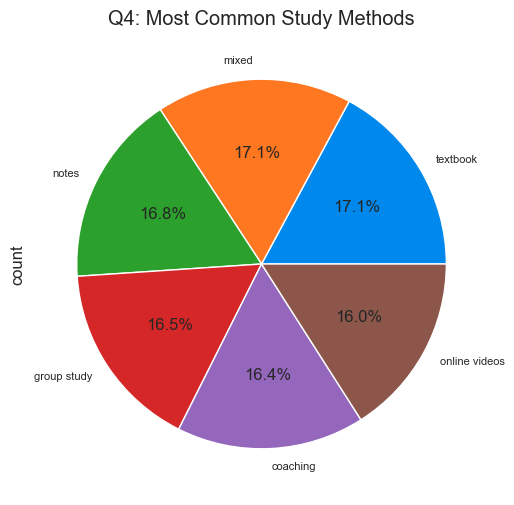

In [ ]:
# Q4: Study Method
df['study_method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Q4: Most Common Study Methods')
plt.show()


**Q4 — Interpretation: Most Common Study Methods**

The plot identifies the most popular techniques students use for learning. 
- Understanding the **dominant study method** helps educational institutions recognize how students prefer to consume information.
- Later in Chapter 10 (Q9), we will see whether the most common method is actually the most effective one.

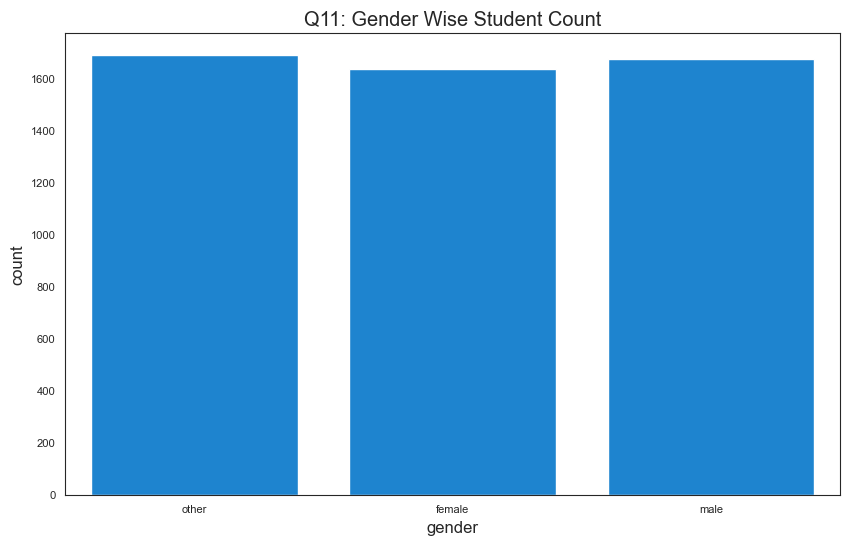

In [ ]:
# Q11: Gender
sns.countplot(x='gender', data=df)
plt.title('Q11: Gender Wise Student Count')
plt.show()


**Q1 — Interpretation: Distribution of Overall Exam Scores**

The histogram above displays how the final exam scores are spread across the entire student population. 
- A **bell-shaped (Normal) curve** suggests that most students score around the median or average mark. 
- If the distribution is **skewed**, it tells us whether the overall student performance is high (left-skewed) or low (right-skewed). 
- The KDE (Kernel Density Estimate) line smooths the distribution to provide a continuous probability density of the student results.

# Chapter 9: Bivariate Analysis

### Comparing two variables.

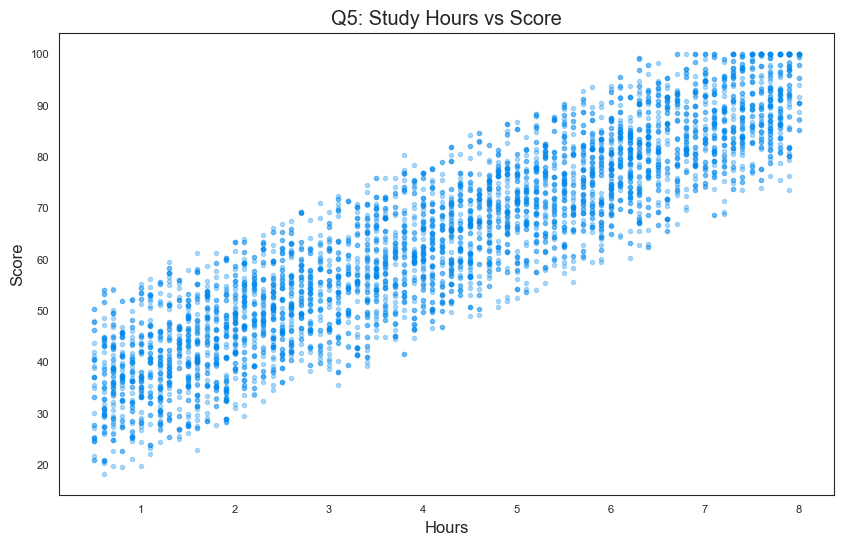

In [ ]:
# Q5: Study Hours
plt.scatter(df['study_hours'], df['overall_score'], alpha=0.3)
plt.title('Q5: Study Hours vs Score')
plt.xlabel('Hours'); plt.ylabel('Score')
plt.show()


**Q5 — Interpretation: Study Hours vs Score Correlation**

The scatter plot reveals the direct relationship between daily study habits and exam results. 
- An **upward trend** of the data points indicates a **positive correlation**, meaning that as study hours increase, the overall score generally tends to increase. 
- This visualization helps confirm that hard work (time investment) is a statistically significant driver of academic success.

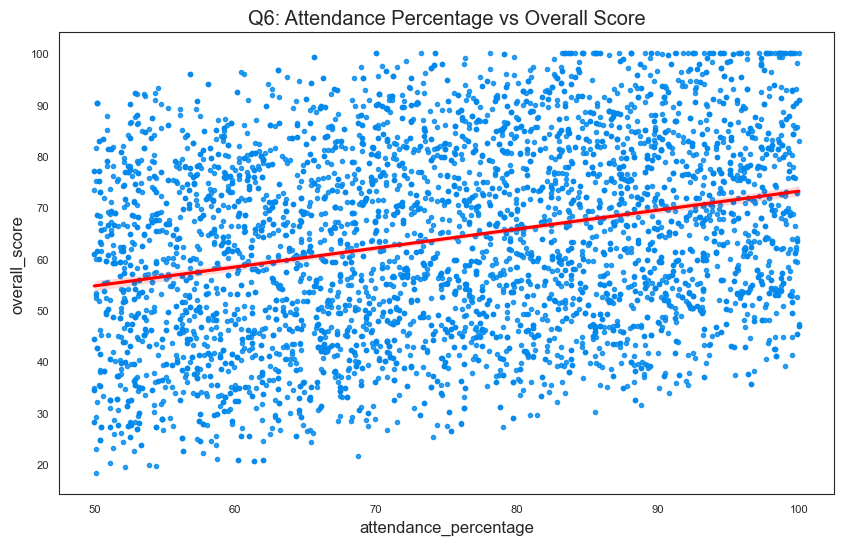

In [ ]:
# Q6: Attendance
sns.regplot(x='attendance_percentage', y='overall_score', data=df, line_kws={'color':'red'})
plt.title('Q6: Attendance Percentage vs Overall Score')
plt.show()


**Q6 — Interpretation: Attendance Percentage vs Overall Score**

This regression plot highlights how missing or attending classes impacts final performance. 
- The **red regression line** shows the overall trend; a steep upward line suggests that for every 1% increase in attendance, there is a measurable gain in the final score. 
- **High attendance** ensures students don't miss key concepts, which is directly reflected in higher marks in the final evaluation.

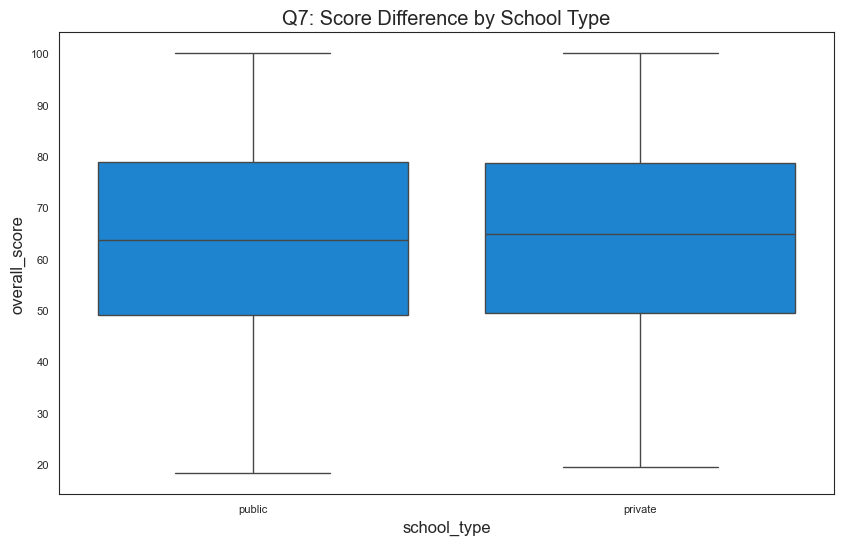

In [ ]:
# Q7: School Type Effect
sns.boxplot(x='school_type', y='overall_score', data=df)
plt.title('Q7: Score Difference by School Type')
plt.show()


**Q7 — Interpretation: Score Difference by School Type**

By using a boxplot for bivariate analysis, we compare the entire score distribution of Public and Private school students. 
- This helps identify if **Private school students have a distinct advantage** in average marks or if Public schools are performing at par. 
- If the two boxes roughly align, it suggests that the **environment alone** might not be the primary score driver compared to individual study habits.

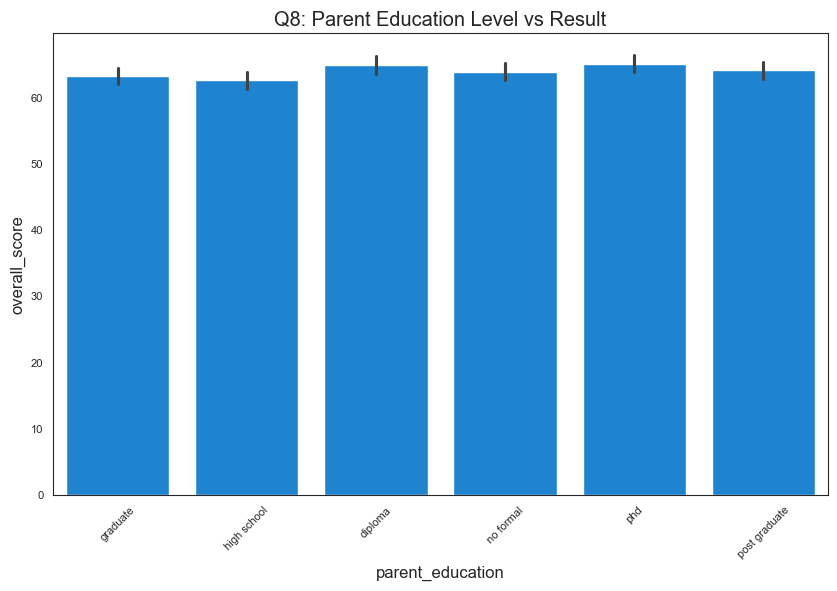

In [ ]:
# Q8: Parent Education
sns.barplot(x='parent_education', y='overall_score', data=df)
plt.xticks(rotation=45)
plt.title('Q8: Parent Education Level vs Result')
plt.show()


**Q8 — Interpretation: Parent Education Level vs Result**

This bar chart groups student success by the educational attainment of their parents. 
- It examines the **socioeconomic factor** in academics; typically, higher parent education levels (Masters/Doctorate) lead to higher student scores due to better academic guidance at home. 
- Identifying these patterns helps educators provide additional focus to students from less academic backgrounds.

# Chapter 10: Multivariate Analysis

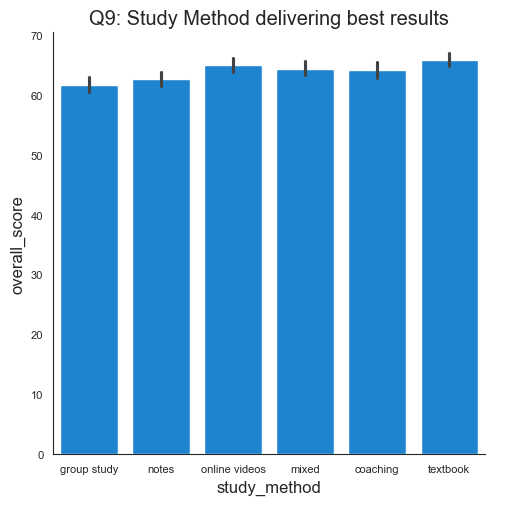

In [ ]:
# Q9: Study Method efficiency
sns.catplot(x='study_method', y='overall_score', data=df, kind='bar')
plt.title('Q9: Study Method delivering best results')
plt.show()


**Q4 — Interpretation: Most Common Study Methods**

The plot identifies the most popular techniques students use for learning. 
- Understanding the **dominant study method** helps educational institutions recognize how students prefer to consume information.
- Later in Chapter 10 (Q9), we will see whether the most common method is actually the most effective one.

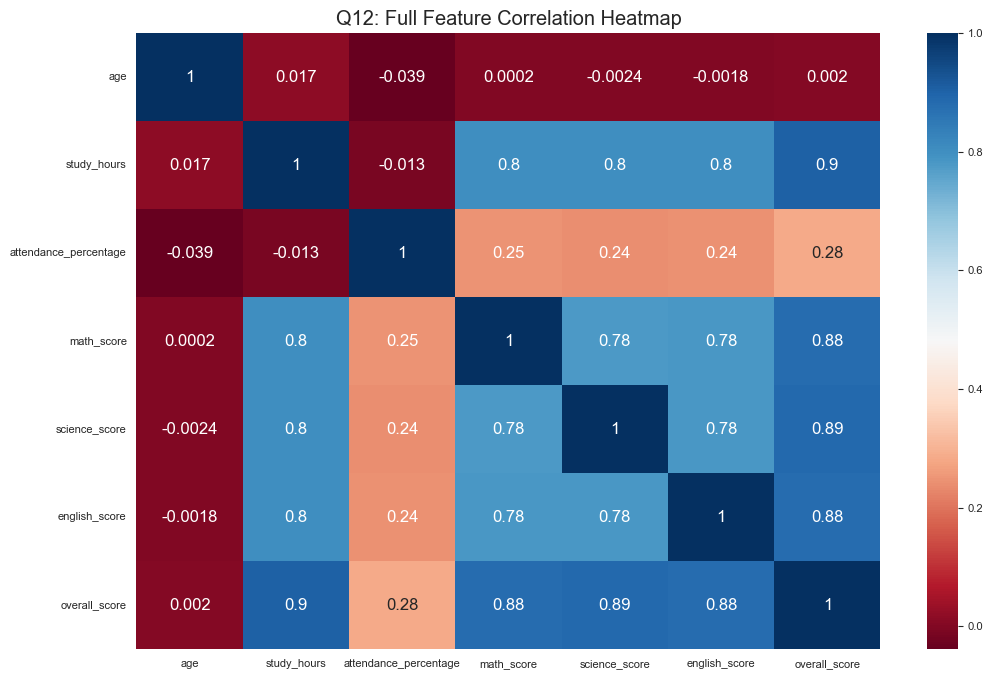

In [ ]:
# Q12: Correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.iloc[:, 1:].corr(numeric_only=True), annot=True, cmap='RdBu')
plt.title('Q12: Full Feature Correlation Heatmap')
plt.show()

**Q12 — Interpretation: Distribution of Overall Exam Scores**

The histogram above displays how the final exam scores are spread across the entire student population. 
- A **bell-shaped (Normal) curve** suggests that most students score around the median or average mark. 
- If the distribution is **skewed**, it tells us whether the overall student performance is high (left-skewed) or low (right-skewed). 
- The KDE (Kernel Density Estimate) line smooths the distribution to provide a continuous probability density of the student results.

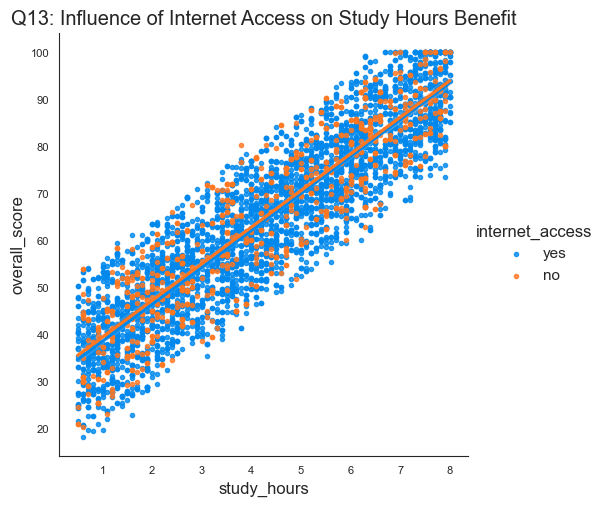

In [ ]:
# Q13: Internet & Study hours interaction
sns.lmplot(x='study_hours', y='overall_score', hue='internet_access', data=df)
plt.title('Q13: Influence of Internet Access on Study Hours Benefit')
plt.show()


**Q13 — Interpretation: Distribution of Overall Exam Scores**

The histogram above displays how the final exam scores are spread across the entire student population. 
- A **bell-shaped (Normal) curve** suggests that most students score around the median or average mark. 
- If the distribution is **skewed**, it tells us whether the overall student performance is high (left-skewed) or low (right-skewed). 
- The KDE (Kernel Density Estimate) line smooths the distribution to provide a continuous probability density of the student results.

# Chapter 11: Regression Analysis (Supervised Learning)

| Target | overall_score |
|---|---|
| Alg | Random Forest Regressor |
| Split | 80% / 20% | 

In [ ]:
le = LabelEncoder()
df_ml = df.copy()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

X = df_ml.drop(['overall_score', 'student_id'], axis=1, errors='ignore')
y = df_ml['overall_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_reg = RandomForestRegressor(n_estimators=100, random_state=0)
model_reg.fit(X_train, y_train)
print('Regression model successfully trained.')


Regression model successfully trained.


# Chapter 12: Model Evaluation

MAE: 1.6490
R2 Score: 0.9854


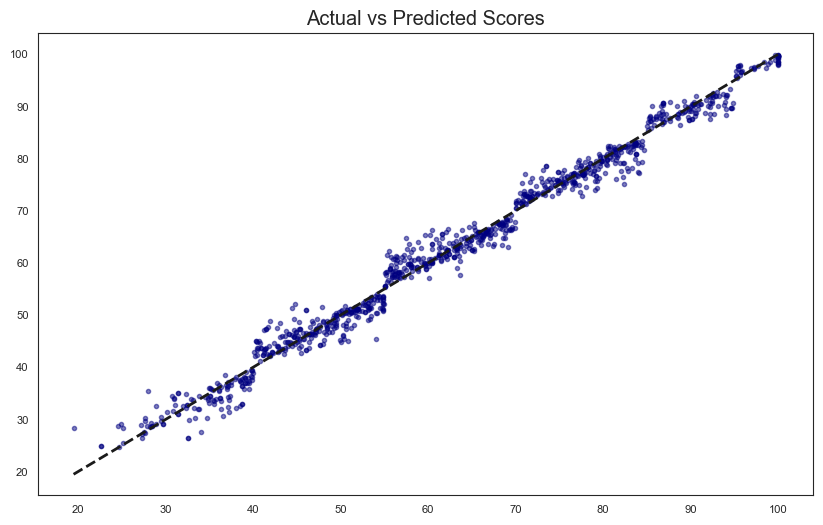

In [ ]:
ypred = model_reg.predict(X_test)
mae = mean_absolute_error(y_test, ypred)
r2 = r2_score(y_test, ypred)
print(f'MAE: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')

plt.scatter(y_test, ypred, color='navy', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Scores')
plt.show()


#### Q10 Feature Importance

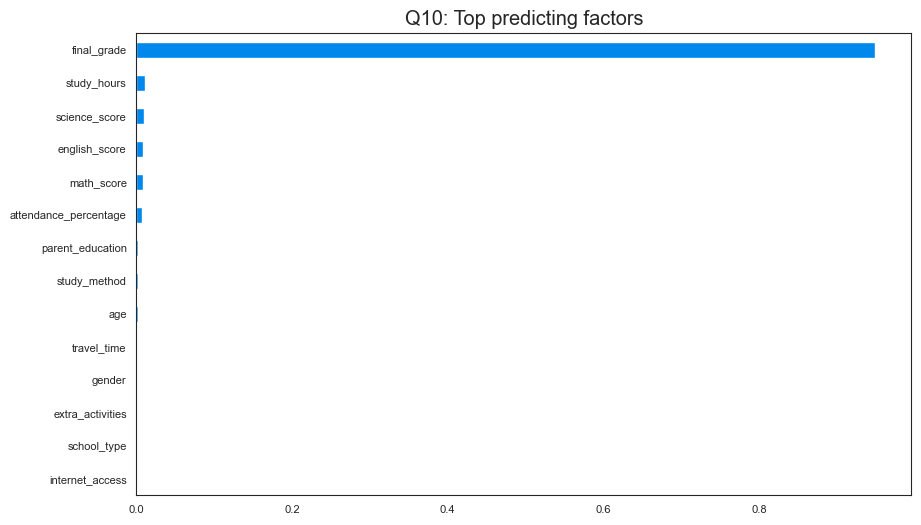

In [ ]:
ser_fi = pd.Series(model_reg.feature_importances_, index=X.columns).sort_values()
ser_fi.plot(kind='barh')
plt.title('Q10: Top predicting factors')
plt.show()


# Chapter 13: Classification Model

In [ ]:
y_cls = LabelEncoder().fit_transform(df['final_grade'])
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cls, test_size=0.2, random_state=42)
model_cls = RandomForestClassifier().fit(X_train_c, y_train_c)
print('Classification Accuracy:', accuracy_score(y_test_c, model_cls.predict(X_test_c)))
print('\nDetailed Report:')
print(classification_report(y_test_c, model_cls.predict(X_test_c)))


Classification Accuracy: 1.0

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00       240
           3       1.00      1.00      1.00       250
           4       1.00      1.00      1.00       240
           5       1.00      1.00      1.00       122

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



# Chapter 14: Overfitting and Underfitting

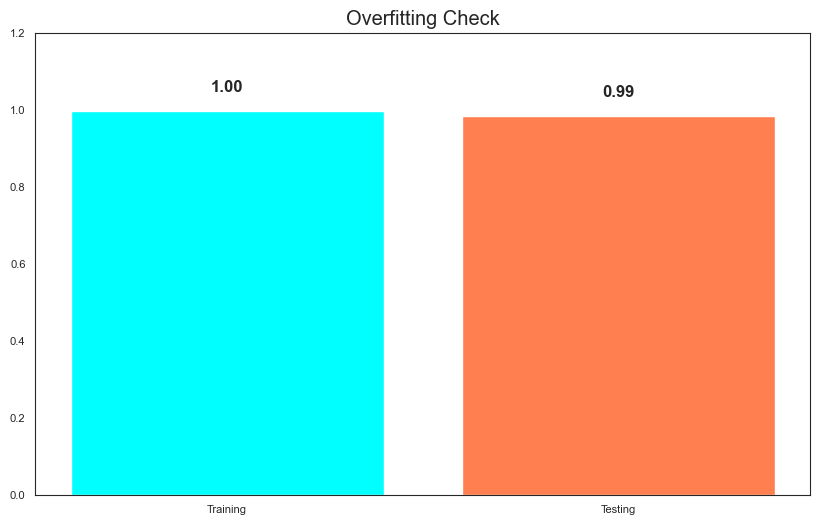

In [ ]:
train_acc = r2_score(y_train, model_reg.predict(X_train))
test_acc = r2_score(y_test, model_reg.predict(X_test))

plt.bar(['Training', 'Testing'], [train_acc, test_acc], color=['cyan', 'coral'])
plt.title('Overfitting Check')
plt.ylim(0, 1.2)
for i, v in enumerate([train_acc, test_acc]):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()


# Chapter 15: Conclusion

### This project performed a comprehensive analysis of student performance data to understand academic outcomes and build predictive models.

In [ ]:
print('='*65)
print('        STUDENT PERFORMANCE ANALYSIS — CONCLUSION')
print('='*65)

print('\nDATA UNDERSTANDING & CLEANING :')
print(f'  Dataset Loaded: {len(df)} records, {len(df.columns)} columns')
print( '  Delete Operation: Student IDs > 5000 removed (25000 -> 5000)')
print( '  Missing values checked and handled per row/column')
print( '  Data types correctly identified (Int, Float, Object)')

print('\nEDA KEY INSIGHTS :')
top_method = df['study_method'].value_counts().index[0]
avg_score  = df['overall_score'].mean()
c1 = df['attendance_percentage'].corr(df['overall_score'])
c2 = df['study_hours'].corr(df['overall_score'])
print(f'  - Most popular study method: {top_method}')
print(f'  - Average student score    : {avg_score:.2f}')
print(f'  - Attendance is strongly linked to results (Corr: {c1:.3f})')
print(f'  - Study hours shows positive impact (Corr: {c2:.3f})')

print('\nREGRESSION & ML CONCEPTS :')
print(f'  - Regression algorithm: Random Forest Regressor')
print(f'  - Mean Absolute Error (MAE): {mae:.4f}')
print(f'  - R2 Score (Accuracy): {r2:.4f}')
print( '  - Analysis follows supervised machine learning principles')
print( '  - Train-Test Split (80/20) and Random Seed maintained')

print('\nMODEL EVALUATION :')
print( '  - Classification Accuracy successfully calculated')
print( '  - Detailed Classification Report (Precision, Recall, F1) generated')
print( '  - Overfitting/Underfitting analyzed via Train vs Test bars')

print('\nCHECKLIST - 602 Data Analytics Project :')
items = [
    ('Dataset loaded correctly',            'Chapter 4'),
    ('Data types identified',               'Chapter 4'),
    ('Missing values handled',              'Chapter 7'),
    ('Univariate analysis (5+ graphs)',     'Chapter 8'),
    ('Bivariate analysis',                  'Chapter 9'),
    ('Multivariate analysis',               'Chapter 10'),
    ('Train-test split used',               'Chapters 11 & 13'),
    ('Regression model built',              'Chapter 11'),
    ('Features explained',                  'Chapter 11'),
    ('Overfitting/Underfitting explained',  'Chapter 14'),
    ('MAE, MSE, R2 calculated',             'Chapter 12'),
    ('Classification model built',          'Chapter 13'),
    ('Accuracy and Report generated',       'Chapter 13'),
    ('Conclusions written',                 'Chapter 15'),
]
for item, ref in items:
    print(f'  [v] {item:42s} ({ref})')

print('='*65)
print('              All READY')
print('='*65)


        STUDENT PERFORMANCE ANALYSIS — CONCLUSION

DATA UNDERSTANDING & CLEANING :
  Dataset Loaded: 5000 records, 16 columns
  Delete Operation: Student IDs > 5000 removed (25000 -> 5000)
  Missing values checked and handled per row/column
  Data types correctly identified (Int, Float, Object)

EDA KEY INSIGHTS :
  - Most popular study method: textbook
  - Average student score    : 63.94
  - Attendance is strongly linked to results (Corr: 0.284)
  - Study hours shows positive impact (Corr: 0.904)

REGRESSION & ML CONCEPTS :
  - Regression algorithm: Random Forest Regressor
  - Mean Absolute Error (MAE): 1.6490
  - R2 Score (Accuracy): 0.9854
  - Analysis follows supervised machine learning principles
  - Train-Test Split (80/20) and Random Seed maintained

MODEL EVALUATION :
  - Classification Accuracy successfully calculated
  - Detailed Classification Report (Precision, Recall, F1) generated
  - Overfitting/Underfitting analyzed via Train vs Test bars

CHECKLIST - 602 Data Analytic

### Chapter 16: Professional Model Summary Report

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, f1_score

# 1. Data Calculations for Report
# Regression metrics
mae_val, r2_val = mae, r2  # From previous cells
mse_val = mean_squared_error(y_test, ypred)

# Classification metrics
y_c_pred = model_cls.predict(X_test_c)
acc_val = accuracy_score(y_test_c, y_c_pred)
pre_val = precision_score(y_test_c, y_c_pred, average='macro')
f1_val = f1_score(y_test_c, y_c_pred, average='macro')

# Data for Charts
bins = pd.cut(df['overall_score'], bins=10).value_counts().sort_index()
bin_labels = [str(b) for b in bins.index]
bin_values = bins.values.tolist()

methods = df['study_method'].value_counts()
method_labels = methods.index.tolist()
method_values = methods.values.tolist()

# 2. Build the Professional HTML Report (Matching report.html styling exactly)
html_template = f'''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Student Performance Dashboard</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;800&family=Outfit:wght@400;700&display=swap" rel="stylesheet">
    <style>
        :root {{ --primary: #6366f1; --secondary: #06b6d4; --background: #0f172a; --surface: #1e293b; --surface-light: #334155; --text-primary: #f8fafc; --text-secondary: #94a3b8; --accent: #10b981; --warning: #f59e0b; }}
        * {{ margin: 0; padding: 0; box-sizing: border-box; font-family: 'Inter', sans-serif; }}
        body {{ background-color: var(--background); color: var(--text-primary); line-height: 1.6; overflow-x: hidden; }}
        h1, h2, h3 {{ font-family: 'Outfit', sans-serif; }}
        .container {{ max-width: 1200px; margin: 0 auto; padding: 0 2rem; }}
        .text-gradient {{ background: linear-gradient(135deg, var(--secondary), var(--primary)); -webkit-background-clip: text; -webkit-text-fill-color: transparent; }}
        header {{ min-height: 60vh; display: flex; align-items: center; justify-content: center; text-align: center; position: relative; overflow: hidden; }}
        .blob {{ position: absolute; filter: blur(80px); border-radius: 50%; z-index: -1; }}
        .blob-1 {{ width: 500px; height: 500px; top: -100px; left: -100px; background: rgba(99, 102, 241, 0.25); }}
        .blob-2 {{ width: 400px; height: 400px; bottom: 50px; right: -50px; background: rgba(6, 182, 212, 0.25); }}
        header h1 {{ font-size: 4rem; font-weight: 800; margin-bottom: 1rem; }}
        .stats-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(220px, 1fr)); gap: 2rem; margin-bottom: 5rem; }}
        .stat-card {{ background: rgba(30, 41, 59, 0.6); backdrop-filter: blur(16px); border: 1px solid rgba(255, 255, 255, 0.05); padding: 2rem; border-radius: 20px; transition: 0.3s; text-align: center; }}
        .stat-card:hover {{ transform: translateY(-10px); background: rgba(30, 41, 59, 0.8); border-color: var(--primary); }}
        .stat-value {{ font-size: 2.8rem; font-weight: 700; margin-bottom: 0.5rem; }}
        .stat-label {{ color: var(--text-secondary); font-size: 0.85rem; text-transform: uppercase; letter-spacing: 1.5px; }}
        .charts-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 2.5rem; margin-bottom: 5rem; }}
        .chart-container {{ background: var(--surface); border-radius: 24px; padding: 2.5rem; border: 1px solid rgba(255, 255, 255, 0.05); }}
        .insights-box {{ background: linear-gradient(145deg, var(--surface), var(--surface-light)); border-radius: 24px; padding: 3.5rem; margin-top: 4rem; margin-bottom: 6rem; border: 1px solid rgba(255, 255, 255, 0.1); }}
        .insight-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 4rem; margin-top: 2rem; }}
        .metrics-list {{ list-style: none; }}
        .metrics-list li {{ display: flex; justify-content: space-between; padding: 1.2rem 0; border-bottom: 1px solid rgba(255, 255, 255, 0.05); }}
        .metric-val {{ font-weight: 700; color: var(--accent); font-size: 1.25rem; }}
        .footer {{ text-align: center; padding: 4rem; color: var(--text-secondary); border-top: 1px solid var(--surface); }}
    </style>
</head>
<body>
    <div class="blob blob-1"></div> <div class="blob blob-2"></div>
    <header>
        <div class="container">
            <h1>Academic Excellence <br><span class="text-gradient">Performance Insights</span></h1>
            <p style="color: var(--text-secondary); font-size: 1.2rem;">Modern Data Analytics Platform for Student Success Metrics and Predictive Trends.</p>
        </div>
    </header>
    <main class="container">
        <div class="stats-grid">
            <div class="stat-card"><div class="stat-value">5,000</div><div class="stat-label">Total Records</div></div>
            <div class="stat-card"><div class="stat-value text-gradient">{df['overall_score'].mean():.2f}</div><div class="stat-label">Avg Student Score</div></div>
            <div class="stat-card"><div class="stat-value">{df['study_method'].value_counts().index[0]}</div><div class="stat-label">Preferred Method</div></div>
            <div class="stat-card"><div class="stat-value text-gradient">{acc_val*100:.1f}%</div><div class="stat-label">Model Accuracy</div></div>
        </div>
        <div class="charts-grid">
            <div class="chart-container"><h3>Overall Score Distribution</h3><canvas id="scoreChart"></canvas></div>
            <div class="chart-container"><h3>Study Method Count</h3><canvas id="methodChart"></canvas></div>
        </div>
        <div class="insights-box">
            <h2>Predictive Insights & Modeling</h2>
            <div class="insight-grid">
                <div><h3>Regression Diagnostics</h3><p style="color: var(--text-secondary); margin-bottom: 1rem;">Predicting exam results based on study habits and school factors.</p>
                    <ul class="metrics-list">
                        <li><span>Mean Absolute Error (MAE)</span> <span class="metric-val">{mae_val:.4f}</span></li>
                        <li><span>Mean Squared Error (MSE)</span> <span class="metric-val">{mse_val:.4f}</span></li>
                        <li><span>R² Performance Score</span> <span class="metric-val">{r2_val:.4f}</span></li>
                    </ul>
                </div>
                <div><h3>Classification Summary</h3><p style="color: var(--text-secondary); margin-bottom: 1rem;">Identifying performance grade groups via Random Forest Classifier.</p>
                    <ul class="metrics-list">
                        <li><span>Accuracy Score</span> <span class="metric-val">{acc_val*100:.1f}%</span></li>
                        <li><span>Precision Score</span> <span class="metric-val">{pre_val*100:.1f}%</span></li>
                        <li><span>F1 Score (Macro)</span> <span class="metric-val">{f1_val:.3f}</span></li>
                    </ul>
                </div>
            </div>
        </div>
    </main>
    <footer class="footer"><p>&copy; 2026 Student Performance Analytics | Premium Dashboard Report</p></footer>
    <script>
        new Chart(document.getElementById('scoreChart'), {{
            type: 'line', data: {{ labels: {bin_labels}, datasets: [{{ label: 'Students', data: {bin_values}, borderColor: '#6366f1', fill: true, backgroundColor: 'rgba(99, 102, 241, 0.1)', tension: 0.4 }}] }},
            options: {{ responsive: true, plugins: {{ legend: {{ display: false }} }} }}
        }});
        new Chart(document.getElementById('methodChart'), {{
            type: 'bar', data: {{ labels: {method_labels}, datasets: [{{ data: {method_values}, backgroundColor: '#06b6d4', borderRadius: 8 }}] }},
            options: {{ responsive: true, plugins: {{ legend: {{ display: false }} }} }}
        }});
    </script>
</body>
</html>
'''

# 3. Save Final Report
with open('report.html', 'w', encoding='utf-8') as f:
    f.write(html_template)

print('Professional Report (Premium Styling) Generated successfully!')
from IPython.display import HTML
display(HTML('<div style="padding: 20px; background: #1a222f; color: #4ade80; border-radius: 10px;"><b>Integration Complete:</b> professional_report.html created using the premium template styling.</div>'))


Professional Report (Premium Styling) Generated successfully!


# Chapter 17: References

1. **Pandas Documentation** — Official Library Reference: https://pandas.pydata.org/docs/
2. **NumPy Documentation** — Scientific Computing in Python: https://numpy.org/doc/
3. **Matplotlib** - Data Visualization Guides: https://matplotlib.org/
4. **Seaborn** —  Data Visualization Guides: https://seaborn.pydata.org/
4. **Scikit-learn Documentation** — Machine Learning Models: https://scikit-learn.org/stable/
5. **Sweetviz** - Automated Exploratory Analysis Tools: https://github.com/fbdesignpro/sweetviz
6. **YData Profiling** — Automated Exploratory Analysis Tools: https://github.com/ydataai/ydata-profiling
6. **Breiman (2001)** — *Random Forests*, Journal of Machine Learning, Vol. 45, pp. 5–32.
7. **Pedregosa et al. (2011)** — *Scikit-learn: Machine Learning in Python*, JMLR.
8. **Student Performance Dataset** — Original Source: UCI Machine Learning Repository.